# Profiler examples

This notebook demonstrates **desilike**'s `desilike.profilers` package: MAP estimation, Fisher covariances, 1D and 2D profile likelihoods, confidence intervals, and grids of conditional maxima. The same high-level API is implemented for several backends (Minuit, SciPy, BOBYQA, Optax).


## 1. Simple example: `MinuitProfiler`

We use the **affine mock data** likelihood from `basic_examples.ipynb`: a line \(y = ax + b\) with Gaussian noise and identity covariance. A profiler minimizes \(-2\log\) posterior (equivalently \(\chi^2\) when the prior is flat), and stores results in a `Profiles` object.

**Steps:** `Likelihood` → `MinuitProfiler(likelihood, seed=...)` → `maximize(niterations=...)` → inspect `profiler.profiles`.


In [ ]:
import sys
#sys.path.insert(0, "~/desilike") # Run this to use the local desilike package (or point to local desilike directory)
import desilike, os

In [2]:
from desilike.base import BaseCalculator
from desilike.likelihoods import BaseGaussianLikelihood
import numpy as np
from matplotlib import pyplot as plt


class AffineModel(BaseCalculator):
    """Straight line; parameters carry wide Gaussian priors (used for reference sampling of starts)."""
    _params = {'a': {'value': 0., 'prior': {'dist': 'norm', 'loc': 0., 'scale': 10.}},
               'b': {'value': 0., 'prior': {'dist': 'norm', 'loc': 0., 'scale': 10.}}}

    def initialize(self, x=None):
        self.x = x

    def calculate(self, a=0., b=0.):
        self.y = a * self.x + b

    def get(self):
        return self.y

    def __getstate__(self):
        return {'x': self.x, 'y': self.y}


class Likelihood(BaseGaussianLikelihood):
    """Fake data around zero; fixed Gaussian covariance."""

    def initialize(self, theory=None):
        self.xdata = np.linspace(0., 1., 10)
        mean = np.zeros_like(self.xdata)
        self.covariance = np.eye(len(self.xdata))
        rng = np.random.RandomState(seed=42)
        y = rng.multivariate_normal(mean, self.covariance)
        super(Likelihood, self).initialize(y, covariance=self.covariance)
        if theory is None:
            theory = AffineModel()
        self.theory = theory
        self.theory.init.update(x=self.xdata)

    @property
    def flattheory(self):
        return self.theory.y

    def plot(self):
        """Data points and theory curve (same as `basic_examples.ipynb`)."""
        ax = plt.gca()
        ax.errorbar(
            self.xdata,
            self.flatdata,
            yerr=np.diag(self.covariance) ** 0.5,
            color='k',
            linestyle='none',
            marker='o',
            label='data',
        )
        ax.plot(self.xdata, self.flattheory, color='r', label='theory')
        ax.grid()
        ax.legend()
        return ax


In [3]:
from desilike import setup_logging
from desilike.profilers import MinuitProfiler

setup_logging()

likelihood = Likelihood()

# `MinuitProfiler` wraps iminuit (MINUIT2). It is the default choice in many DESI examples.
# `seed` fixes RNG draws for random starting points when `start` is not provided.
profiler = MinuitProfiler(likelihood, seed=42)

# `niterations` = number of independent minimizations from different starts (multi-start).
# The concatenated result keeps all runs; use `bestfit.logposterior.argmax()` for the global best.
profiles = profiler.maximize(niterations=5)

print(profiles.to_stats(tablefmt='pretty'))


[000000.11] [0/1] 04-01 00:26  MinuitProfiler            INFO     Varied parameters: ['a', 'b'].
[000000.63] [0/1] 04-01 00:26  MinuitProfiler            INFO     Successfully jit input likelihood.
+-----------------------------------+--------+---------+-------+
| chi2 / (10 - 2) = 4.70 / 8 = 0.59 | varied | bestfit | error |
+-----------------------------------+--------+---------+-------+
|                 a                 |  True  |  -0.06  | 0.98  |
|                 b                 |  True  |  0.48   | 0.58  |
+-----------------------------------+--------+---------+-------+


Visual check (**same as `basic_examples.ipynb`**): evaluate the likelihood at the **global MAP** (`index='argmax'` when several starts are stored), then plot data with error bars and the best-fit line.


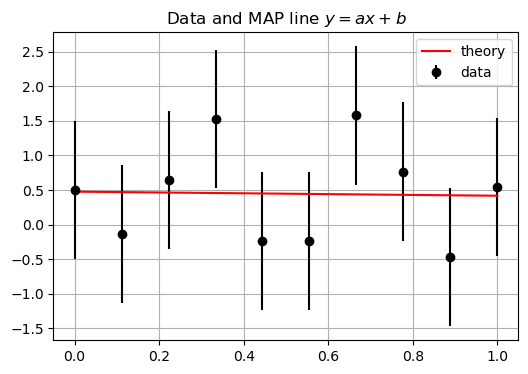

In [4]:
# Pipeline must be run at the MAP parameters so `theory.y` matches the fit.
likelihood(**profiles.bestfit.choice(index='argmax', varied=True))

plt.figure(figsize=(6, 4))
likelihood.plot()
plt.title(r'Data and MAP line $y = ax + b$')
plt.show()


**Outputs:** `profiles.bestfit` contains parameter values and `logposterior` per restart. When available, `profiles.error` and `profiles.covariance` come from the optimizer Hessian (Minuit). For production BAO fits, replace this likelihood with `ObservablesGaussianLikelihood` + clustering observable as in `bao_examples.ipynb`.


## 2. More complete tour of `BaseProfiler`

`BaseProfiler` (see `desilike/profilers/base.py`) defines the shared API:

| Method | What it adds to `profiles` | Idea |
|--------|------------------------------|------|
| `maximize` | `start`, `bestfit`, often `error`, `covariance` | MAP fit |
| `covariance` | `covariance` (via `Fisher`) | Gaussian uncertainty at the best fit |
| `profile` | `profile` | 1D profile: scan one parameter, re-optimize others |
| `interval` | `interval` | Confidence intervals from \(\Delta\chi^2\) |
| `contour` | `contour` | 2D closed contours |
| `grid` | `grid` | Best fit constrained on a grid (conditional maxima) |

Here we set **`rescale=True`**: parameters are scaled internally so typical step sizes \(\sim 1\), using diagonal spreads from **parameter proposals** when no external covariance is passed (see `save_fn` / `profiles` kwargs to persist or append results).

**Note:** Profiling routines call the likelihood many times—use modest `size` for expensive theories.


In [5]:
# New likelihood instance (clean parameter state).
likelihood2 = Likelihood()

profiler = MinuitProfiler(
    likelihood2,
    seed=42,
    rescale=True,
    # covariance=None  # default: build diagonal scale from `proposal` (see docstring)
    # save_fn='_tests/profiles_affine.npy',  # optional: save after each major step
)

# --- MAP: multiple starts to reduce risk of local minima ---
profiler.maximize(niterations=3)

# --- Fisher matrix at the best fit (adds/updates `profiles.covariance`) ---
# This does not replace the profile likelihood below; it is a fast quadratic approximation.
profiler.covariance()

# --- 1D profile likelihoods: scan `a` and `b`, maximizing over the other parameter at each point ---
profiler.profile(params=['a', 'b'], size=25, cl=2)

# --- 1D confidence intervals (from profile construction; `cl=1` ≈ 68% for 1 parameter) ---
profiler.interval(params=['a', 'b'], cl=1)

# --- 2D contour in the (`a`, `b`) plane at the same confidence notion as `cl` ---
profiler.contour(params=['a', 'b'], cl=1)

# --- Grid of conditional maxima: fix `a` on a 1D grid, re-fit `b` each time ---
# Useful for quick scans or visibly non-Gaussian posteriors.
profiler.grid(params=['a'], size=20, cl=2)

print(profiler.profiles)


[000001.40] [0/1] 04-01 00:26  MinuitProfiler            INFO     Varied parameters: ['a', 'b'].
[000001.52] [0/1] 04-01 00:26  MinuitProfiler            INFO     Successfully jit input likelihood.
[000001.71] [0/1] 04-01 00:26  Differentiation           INFO     Varied parameters: ['a', 'b'].
[000002.55] [0/1] 04-01 00:26  Differentiation           INFO     Using auto-differentiation for parameter a.
[000002.60] [0/1] 04-01 00:26  Differentiation           INFO     Using auto-differentiation for parameter b.
[000002.60] [0/1] 04-01 00:26  Differentiation           INFO     Differentiation will evaluate 1 points.
[000003.61] [0/1] 04-01 00:26  MinuitProfiler            INFO     Successfully jit input likelihood.
[000003.79] [0/1] 04-01 00:26  MinuitProfiler            INFO     Successfully jit input likelihood.
[000004.23] [0/1] 04-01 00:26  MinuitProfiler            INFO     Successfully jit input likelihood.
[000004.62] [0/1] 04-01 00:26  MinuitProfiler            INFO     Successful

/global/homes/k/kstoreyf/desilike/desilike/samples/plotting.py:865: SyntaxWarning: invalid escape sequence '\D'
  """


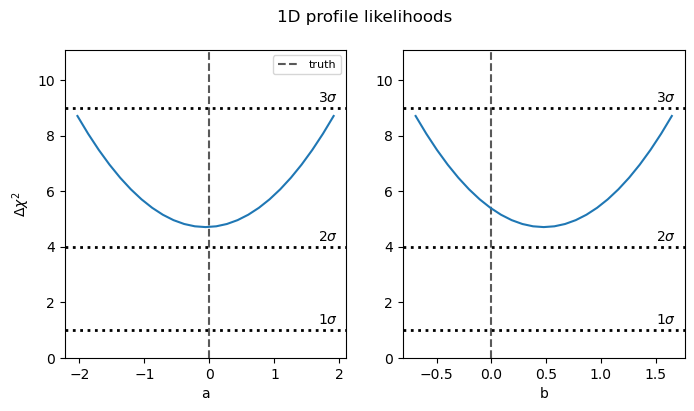

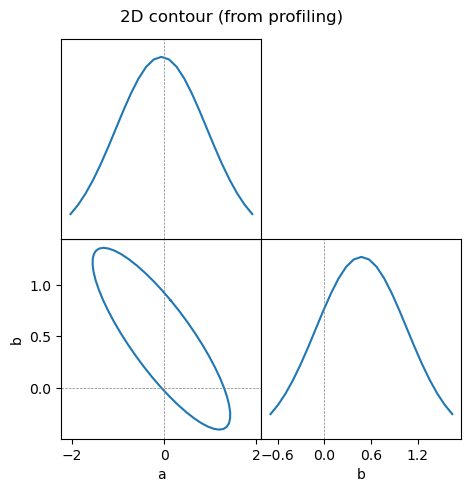

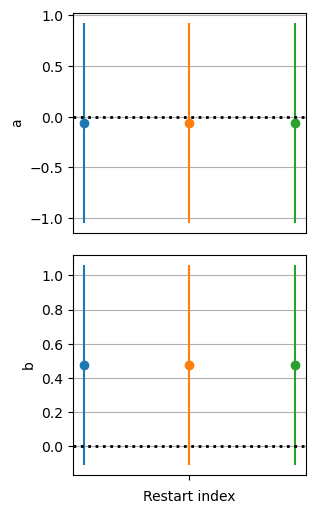

In [6]:
from desilike.samples import plotting
from matplotlib import pyplot as plt

# Generative truth: mock data drawn from N(0, I) about y = 0, i.e. a = b = 0.
TRUTH_A, TRUTH_B = 0., 0.

# 1D profiles: Δχ² vs each parameter; mark the true (a, b) with vertical lines.
fig = plotting.plot_profile(profiler.profiles, params=['a', 'b'])
for i, (ax, tval) in enumerate(zip(fig.axes, [TRUTH_A, TRUTH_B])):
    ax.axvline(
        tval, color='0.35', linestyle='--', linewidth=1.5, zorder=0,
        label='truth' if i == 0 else None,
    )
fig.axes[0].legend(loc='best', fontsize=8)
plt.suptitle('1D profile likelihoods')
plt.show()

# Corner-style contours; `truths` draws reference lines in 1D marginals.
fig2 = plotting.plot_triangle_contours(
    profiler.profiles, params=['a', 'b'], cl=1, truths={'a': TRUTH_A, 'b': TRUTH_B}
)
plt.suptitle('2D contour (from profiling)')
plt.show()

# Best-fit values across MAP restarts; horizontal truth line per panel.
# `ids` must be non-empty: plot_aligned_stacked hides the x-axis when `ids` is None,
# so the bottom `set_xlabel` would not appear (see desilike.samples.plotting.plot_aligned_stacked).
fig3 = plotting.plot_aligned_stacked(
    profiler.profiles,
    params=['a', 'b'],
    truths={'a': TRUTH_A, 'b': TRUTH_B},
    ids=[''],
)
fig3.axes[-1].set_xlabel('Restart index')
plt.show()


**Persistence:** pass `save_fn='path.npy'` to the profiler constructor to write `profiles` after `maximize`, `covariance`, `profile`, etc. You can also pass `profiles=existing` to **append** new results to a previous run.

**BAO:** the same calls apply after `likelihood = ObservablesGaussianLikelihood(...)` with `qiso` / `qpar` / `qper` profiling—see `bao_examples.ipynb` cells that call `profiler.profile(params=['qiso'], grid=grid)`.


## 3. Comparing profiler backends

If **Optax** fails with `np.infty` on **NumPy 2+**, your environment is using an older `desilike` build. Reinstall from a checkout of this repo, e.g. `python -m pip install -e .` from the package root, or point `PYTHONPATH` at your local `desilike/`.

`desilike.profilers` exports:

- **`MinuitProfiler`** — robust, widely used (requires `iminuit`)
- **`ScipyProfiler`** — `scipy.optimize.minimize` wrappers (`method='L-BFGS-B'`, …)
- **`BOBYQAProfiler`** — derivative-free, bounds-friendly (`pybobyqa`)
- **`OptaxProfiler`** — gradient-based (`jax` + `optax`)

Each implements the same `maximize` / `profile` / … interface. The code below runs **`maximize` then `contour`** for each backend that loads successfully, then overlays **2D Δχ² contours** with distinct colors and linestyles. **`plot_triangle_contours` assigns increasing `zorder`** so the **first** backend in the list (Minuit, solid) is **underneath** and **later** backends stack on top—the cell order ends with **BOBYQA** so that curve is easiest to see on top of the others. Skipped backends print the reason (missing dependency, etc.). Use **one fresh `Likelihood()` per profiler** so optimizers do not share a stale calculator state.



[000006.40] [0/1] 04-01 00:26  MinuitProfiler            INFO     Varied parameters: ['a', 'b'].
[000006.53] [0/1] 04-01 00:26  MinuitProfiler            INFO     Successfully jit input likelihood.
[000006.73] [0/1] 04-01 00:26  MinuitProfiler            INFO     Successfully jit input likelihood.
[000007.20] [0/1] 04-01 00:26  MinuitProfiler            INFO     Successfully jit input likelihood.
profs <desilike.samples.profiles.Profiles object at 0x7f11702ef1a0>
[000007.68] [0/1] 04-01 00:26  ScipyProfiler             INFO     Varied parameters: ['a', 'b'].
[000007.82] [0/1] 04-01 00:26  ScipyProfiler             INFO     Successfully jit input likelihood.
[000008.00] [0/1] 04-01 00:26  ScipyProfiler             INFO     Successfully jit input likelihood.
[000008.18] [0/1] 04-01 00:26  ScipyProfiler             INFO     Successfully jit input likelihood.
profs <desilike.samples.profiles.Profiles object at 0x7f11782b8590>
[000008.72] [0/1] 04-01 00:26  BOBYQAProfiler            INFO   

/global/homes/k/kstoreyf/desilike/desilike/parameter.py:542: RuntimeWarning: invalid value encountered in divide
  new = getattr(ufunc, method)(*input_values, **kwargs)


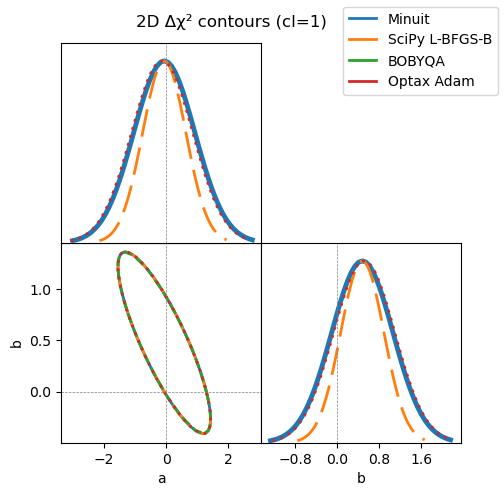

In [7]:
from desilike.samples import plotting
from matplotlib import pyplot as plt

from desilike.profilers import MinuitProfiler, ScipyProfiler, BOBYQAProfiler, OptaxProfiler


def run_backend(label, cls, **kwargs):
    """MAP, then 2D `contour` at cl=1; returns label, profiles, and best-fit scalars."""
    like = Likelihood()
    prof = cls(like, seed=123, **kwargs)
    prof.maximize(niterations=2)
    # Same profile-likelihood surface for every backend — contours should lie on top of each other.
    prof.contour(params=['a', 'b'], cl=1)
    p = prof.profiles
    ix = p.bestfit.logposterior.argmax()
    bf = p.bestfit.choice(index=ix, params=['a', 'b'], return_type='dict')
    return label, p, bf['a'], bf['b'], float(p.bestfit.logposterior[ix])


# Order matters for drawing: first = lowest z-order (bottom); last = on top.
# Keep Minuit (solid) first; put BOBYQA last so its contour sits above the others.
# Linestyles are chosen to be visually distinct (incl. custom dash patterns).
backends = [
    ('Minuit', MinuitProfiler, {}, '-', 'C0'),
    ('SciPy L-BFGS-B', ScipyProfiler, {'method': 'L-BFGS-B'}, (0, (10, 4)), 'C1'),
    ('BOBYQA', BOBYQAProfiler, {}, '--', 'C2'),
    ('Optax Adam', OptaxProfiler, {'method': 'adam'}, (0, (1, 2)), 'C3'),
]

results = []
profile_list = []
labels_plot = []
linestyles_plot = []
colors_plot = []

for label, cls, kw, ls, col in backends:
    try:
        lab, profs, a, b, lp = run_backend(label, cls, **kw)
        print('profs', profs)
        results.append((lab, a, b, lp))
        profile_list.append(profs)
        labels_plot.append(lab)
        linestyles_plot.append(ls)
        colors_plot.append(col)
    except Exception as exc:
        print(f'{label}: skipped ({type(exc).__name__}: {exc})')

if results:
    print(f'{"backend":>15} {"a":>12} {"b":>12} {"logpost":>12}')
    for label, a, b, lp in results:
        print(f'{label:>15} {a:12.6f} {b:12.6f} {lp:12.4f}')

    if profile_list:
        # Keep original draw order (Minuit first = bottom), then thicken Minuit lines in place.
        fig = plotting.plot_triangle_contours(
            profile_list,
            params=['a', 'b'],
            labels=labels_plot,
            colors=colors_plot,
            linestyles=linestyles_plot,
            cl=1,
            truths={'a': 0., 'b': 0.},
            kw_contour={'linewidth': 2.0},
        )
        minuit_idx = next((i for i, lab in enumerate(labels_plot) if lab == 'Minuit'), None)
        if minuit_idx is not None:
            minuit_color = colors_plot[minuit_idx]
            for ax in fig.axes:
                for line in ax.lines:
                    if line.get_color() == minuit_color:
                        line.set_linewidth(3.5)
        plt.suptitle('2D Δχ² contours (cl=1)')
        plt.show()
else:
    print('No backend completed successfully.')



The contours generally agree, except for the SciPy L-BFGS-B implementation (more investigation needed). The bobyqa implementaiton isn't showing 1D marginalized  contours for some reason.